In [2]:
!pip install pandas numpy scikit-learn imbalanced-learn xgboost lightgbm tensorflow matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import joblib
import gc
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import roc_curve, roc_auc_score, auc
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import joblib
import os
import numpy as np

warnings.filterwarnings("ignore")
os.environ["PYTHONHASHSEED"] = "42"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

3. Configuracion general

In [4]:
@dataclass
class Config:
    input_file: str = "transformed_it_ot.csv"
    label_col: str = "traffic_label"
    drop_cols: tuple = ("line_number", "attack_type")
    test_size: float = 0.20
    random_state: int = 42
    max_rows_for_full_train: int = 2500000
    k_best: int = 0
    use_pca: bool = True
    pca_variance: float = 0.90
    smote_k_neighbors: int = 5
    dnn_epochs: int = 20
    dnn_batch_size: int = 1024
    dnn_patience: int = 5
    n_splits: int = 3
    use_autoencoder: bool = True
    ae_latent_dim: int = 4
    ae_epochs: int = 25
    ae_batch_size: int = 1024
    ae_patience: int = 6
    ae_threshold_percentile: int = 95
    ae_max_normal_samples: int = 500000

cfg = Config()
print(cfg)

Config(input_file='transformed_it_ot.csv', label_col='traffic_label', drop_cols=('line_number', 'attack_type'), test_size=0.2, random_state=42, max_rows_for_full_train=2500000, k_best=0, use_pca=True, pca_variance=0.9, smote_k_neighbors=5, dnn_epochs=20, dnn_batch_size=1024, dnn_patience=5, n_splits=3, use_autoencoder=True, ae_latent_dim=4, ae_epochs=25, ae_batch_size=1024, ae_patience=6, ae_threshold_percentile=95, ae_max_normal_samples=500000)


4. Funciones auxiliares

In [5]:
def downcast_numeric(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="float")
        elif pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="integer")
    return df

def reduce_memory(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = downcast_numeric(df)
    return df

def gc_clean(*objs):
    for obj in objs:
        del obj
    gc.collect()

5. Carga y limpieza inicial

In [6]:
print(cfg.input_file)

transformed_it_ot.csv


In [7]:
print("Cargando dataset...")
df = pd.read_csv(cfg.input_file, low_memory=False, encoding="utf-8-sig")

# Normalizar nombres de columnas
df.columns = (
    df.columns.astype(str)
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
    .str.lower()
)

print("Columnas detectadas:")
print(df.columns.tolist())

# Eliminar todas las filas con attack_type == 2

if "attack_type" not in df.columns:
    raise KeyError("No existe la columna attack_type en el dataset.")

print("Forma antes de eliminar attack_type 2:", df.shape)
print("Cantidad attack_type 2 antes:", (df["attack_type"] == 2).sum())

df = df[df["attack_type"] != 2].reset_index(drop=True)

print("Forma despues de eliminar attack_type 2:", df.shape)
print("Cantidad attack_type 2 despues:", (df["attack_type"] == 2).sum())

leakage_cols = [c for c in cfg.drop_cols if c in df.columns]
if leakage_cols:
    df = df.drop(columns=leakage_cols)
    print("Columnas eliminadas por leakage:", leakage_cols)

# Buscar la columna objetivo de forma robusta
posibles_labels = ["traffic_label", "label", "attack_label", "target", "class"]
col_objetivo = None
for c in posibles_labels:
    if c in df.columns:
        col_objetivo = c
        break

if col_objetivo is None:
    raise KeyError(
        "No se encontro una columna objetivo valida. "
        "Se esperaba traffic_label o un nombre equivalente."
    )

cfg.label_col = col_objetivo
print("Columna objetivo detectada:", cfg.label_col)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=[cfg.label_col]).reset_index(drop=True)
df[cfg.label_col] = df[cfg.label_col].astype("int32")

df = reduce_memory(df)

print("Forma despues de limpieza:", df.shape)
print("Memoria aproximada (MB):", round(df.memory_usage(deep=True).sum() / 1024**2, 2))
gc.collect()

df.head()

Cargando dataset...
Columnas detectadas:
['src_port', 'dst_port', 'protocol', 'duration_ms', 'bidirectional_packets', 'bidirectional_bytes', 'src2dst_packets', 'dst2src_packets', 'src2dst_bytes', 'dst2src_bytes', 'src2dst_duration_ms', 'dst2src_duration_ms', 'application_name', 'application_category', 'attack_type', 'traffic_label', 'line_number', 'log_length', 'device_type', 'hour', 'minute', 'second']
Forma antes de eliminar attack_type 2: (3907536, 22)
Cantidad attack_type 2 antes: 1681665
Forma despues de eliminar attack_type 2: (2225871, 22)
Cantidad attack_type 2 despues: 0
Columnas eliminadas por leakage: ['line_number', 'attack_type']
Columna objetivo detectada: traffic_label
Forma despues de limpieza: (2225871, 20)
Memoria aproximada (MB): 127.37


,src_port,dst_port,protocol,duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_packets,dst2src_packets,src2dst_bytes,dst2src_bytes,src2dst_duration_ms,dst2src_duration_ms,application_name,application_category,traffic_label,log_length,device_type,hour,minute,second
0,-2.740926,-0.353949,-1.153072,-0.159071,-0.006939,-0.016591,-0.004337,-0.006445,-0.010569,-0.018081,-0.142451,-0.146354,100,15,0,-0.643270,47,15,52,24
1,0.833272,-0.209669,1.697311,-0.157960,-0.005903,-0.011866,-0.003011,-0.006445,-0.004041,-0.018081,-0.141335,-0.146354,160,20,0,-0.643270,47,15,52,36
2,-2.740926,-0.353949,-1.153072,-0.159071,-0.006939,-0.016591,-0.004337,-0.006445,-0.010569,-0.018081,-0.142451,-0.146354,100,15,0,-1.164886,47,15,52,25
3,-1.362775,-0.349924,1.697311,-0.158824,-0.006766,-0.015823,-0.004337,-0.006132,-0.010413,-0.016758,-0.142451,-0.146354,46,15,0,-0.904078,47,15,53,4
4,-2.740926,-0.353949,-1.153072,-0.159071,-0.006939,-0.016591,-0.004337,-0.006445,-0.010569,-0.018081,-0.142451,-0.146354,100,15,0,-0.643270,47,15,52,23


6. Separacion train/test

In [8]:
# Revalidacion estricta antes del split
print("Columnas actuales en df:")
print(df.columns.tolist())

# Normalizar otra vez por seguridad
df.columns = df.columns.astype(str).str.strip().str.lower()

# Si la etiqueta quedo como indice por algun cambio previo, la recupero
if cfg.label_col not in df.columns:
    if cfg.label_col in df.index.names:
        df = df.reset_index()
        df.columns = df.columns.astype(str).str.strip().str.lower()

# Detectar etiqueta de forma segura
posibles_labels = ["traffic_label", "label", "attack_label", "target", "class"]
col_objetivo = None

for c in posibles_labels:
    if c in df.columns:
        col_objetivo = c
        break

if col_objetivo is None:
    raise KeyError(
        f"No se encontro una columna objetivo valida. Columnas disponibles: {df.columns.tolist()}"
    )

cfg.label_col = col_objetivo
print("Columna objetivo final:", cfg.label_col)

y = df[cfg.label_col].astype("int32").values
X = df.drop(columns=[cfg.label_col])

feature_names = X.columns.tolist()

print("Numero de features:", len(feature_names))
print("Distribucion de clases:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y,
    test_size=cfg.test_size,
    random_state=cfg.random_state,
    stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
gc_clean(df, X, y)

Columnas actuales en df:
['src_port', 'dst_port', 'protocol', 'duration_ms', 'bidirectional_packets', 'bidirectional_bytes', 'src2dst_packets', 'dst2src_packets', 'src2dst_bytes', 'dst2src_bytes', 'src2dst_duration_ms', 'dst2src_duration_ms', 'application_name', 'application_category', 'traffic_label', 'log_length', 'device_type', 'hour', 'minute', 'second']
Columna objetivo final: traffic_label
Numero de features: 19
Distribucion de clases:
1    2140412
0      85459
Name: count, dtype: int64
X_train: (1780696, 19) X_test: (445175, 19)


7. Escalado

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.astype("float32"))
X_test_scaled = scaler.transform(X_test.astype("float32"))

X_train_scaled = X_train_scaled.astype("float32")
X_test_scaled = X_test_scaled.astype("float32")

print("Escalado completado.")
gc.collect()

Escalado completado.


0

8. Optimizacion de caracteristicas

In [ ]:
n_features = X_train_scaled.shape[1]
if cfg.k_best <= 0:
    k_best = min(10, n_features)
else:
    k_best = min(cfg.k_best, n_features)

selector = SelectKBest(score_func=mutual_info_classif, k=k_best)
X_train_fs = selector.fit_transform(X_train_scaled, y_train)
X_test_fs = selector.transform(X_test_scaled)

X_train_fs = X_train_fs.astype("float32")
X_test_fs = X_test_fs.astype("float32")

selected_features = [feature_names[i] for i in selector.get_support(indices=True)]
print("Features seleccionadas:", selected_features)
print("Shape train:", X_train_fs.shape, "Shape test:", X_test_fs.shape)
gc.collect()

Features seleccionadas: ['dst_port', 'protocol', 'bidirectional_bytes', 'src2dst_bytes', 'dst2src_bytes', 'application_name', 'application_category', 'log_length', 'device_type', 'hour']
Shape train: (1780696, 10) Shape test: (445175, 10)


322

9. PCA opcional

In [11]:
if cfg.use_pca:
    pca = PCA(
        n_components=cfg.pca_variance,
        svd_solver="full",
        random_state=cfg.random_state
    )

    X_train_final = pca.fit_transform(X_train_fs)
    X_test_final = pca.transform(X_test_fs)

    X_train_final = X_train_final.astype("float32")
    X_test_final = X_test_final.astype("float32")

    print("PCA activado")
    print("Componentes PCA:", pca.n_components_)
    print("Varianza acumulada:", round(pca.explained_variance_ratio_.sum(), 4))
    print("Shape train final:", X_train_final.shape)
    print("Shape test final :", X_test_final.shape)
else:
    X_train_final = X_train_fs
    X_test_final = X_test_fs

    print("PCA desactivado")
    print("Shape train final:", X_train_final.shape)
    print("Shape test final :", X_test_final.shape)

gc.collect()

PCA activado
Componentes PCA: 7
Varianza acumulada: 0.9268
Shape train final: (1780696, 7)
Shape test final : (445175, 7)


0

10. Funcion del Autoencoder

In [12]:
def build_autoencoder(input_dim, latent_dim=4):
    hidden_dim = max(8, input_dim * 2)

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(hidden_dim, activation="relu"),
        BatchNormalization(),
        Dropout(0.10),
        Dense(latent_dim, activation="relu"),
        Dense(hidden_dim, activation="relu"),
        Dense(input_dim, activation="linear")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="mse"
    )
    return model


def reconstruction_error(model, X, batch_size=1024):
    X_hat = model.predict(X, batch_size=batch_size, verbose=0)
    err = np.mean(np.square(X - X_hat), axis=1)
    return err.astype("float32")

11. Entrenar Autoencoder con Trafico Normal

In [13]:
if cfg.use_autoencoder:
    X_train_normal = X_train_final[y_train == 0].astype("float32")

    if X_train_normal.shape[0] > cfg.ae_max_normal_samples:
        rng = np.random.default_rng(cfg.random_state)
        idx = rng.choice(
            X_train_normal.shape[0],
            size=cfg.ae_max_normal_samples,
            replace=False
        )
        X_train_normal_fit = X_train_normal[idx]
    else:
        X_train_normal_fit = X_train_normal

    X_train_normal_fit, X_val_normal = train_test_split(
        X_train_normal_fit,
        test_size=0.15,
        random_state=cfg.random_state
    )

    autoencoder = build_autoencoder(
        input_dim=X_train_final.shape[1],
        latent_dim=cfg.ae_latent_dim
    )

    ae_callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=cfg.ae_patience,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=max(2, cfg.ae_patience // 2),
            min_lr=1e-6
        )
    ]

    ae_history = autoencoder.fit(
        X_train_normal_fit,
        X_train_normal_fit,
        validation_data=(X_val_normal, X_val_normal),
        epochs=cfg.ae_epochs,
        batch_size=cfg.ae_batch_size,
        shuffle=True,
        verbose=1,
        callbacks=ae_callbacks
    )

    ae_train_normal_scores = reconstruction_error(
        autoencoder,
        X_train_normal_fit,
        batch_size=cfg.ae_batch_size
    )

    ae_threshold = np.percentile(
        ae_train_normal_scores,
        cfg.ae_threshold_percentile
    )

    print("Autoencoder entrenado solo con trafico normal")
    print("Threshold AE:", ae_threshold)
else:
    autoencoder = None
    ae_history = None
    ae_threshold = None
    ae_train_normal_scores = None

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 3.2249 - val_loss: 2.1914 - learning_rate: 0.0010
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7739 - val_loss: 0.8305 - learning_rate: 0.0010
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0406 - val_loss: 0.5438 - learning_rate: 0.0010
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8629 - val_loss: 0.4473 - learning_rate: 0.0010
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7664 - val_loss: 0.3795 - learning_rate: 0.0010
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7061 - val_loss: 0.3228 - learning_rate: 0.0010
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6523 - val_loss: 0.2745 - learning_rate: 0.0010
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6072 - val_loss: 0.2355 - learning_rate: 0.0010
Epoch 9/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5566 - val_loss: 0.2010 - learning_rate: 0.0010
Epoch 10/25
57/57 ━━━━━━━━━━

12. SMOTE solo sobre train

In [14]:
minority_count = int(np.min(np.bincount(y_train)))
k_neighbors = min(cfg.smote_k_neighbors, max(1, minority_count - 1))

smote = SMOTE(
    sampling_strategy="auto",
    random_state=cfg.random_state,
    k_neighbors=k_neighbors
)

X_train_bal, y_train_bal = smote.fit_resample(X_train_final, y_train)

X_train_bal = X_train_bal.astype("float32")
y_train_bal = y_train_bal.astype("int32")

print("Despues de SMOTE:", X_train_bal.shape, np.bincount(y_train_bal))
gc.collect()

Despues de SMOTE: (3424658, 7) [1712329 1712329]


1306

13. Calcular scores del autoencoder para train y test

In [15]:
if cfg.use_autoencoder:
    ae_train_scores = reconstruction_error(
        autoencoder,
        X_train_bal.astype("float32"),
        batch_size=cfg.ae_batch_size
    ).reshape(-1, 1)

    ae_test_scores = reconstruction_error(
        autoencoder,
        X_test_final.astype("float32"),
        batch_size=cfg.ae_batch_size
    ).reshape(-1, 1)

    print("Autoencoder scores calculados")
else:
    ae_train_scores = None
    ae_test_scores = None

Autoencoder scores calculados


14. Modelos base

In [16]:
def build_dnn(input_dim: int) -> tf.keras.Model:
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.20),
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.15),
        Dense(16, activation="relu"),
        Dropout(0.10),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

def build_xgb(y_ref):
    pos = max(1, int(np.sum(y_ref == 1)))
    neg = max(1, int(np.sum(y_ref == 0)))
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=180,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=1,
        subsample=0.85,
        colsample_bytree=0.85,
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
        scale_pos_weight=neg / pos
    )

def build_lgbm(y_ref):
    pos = max(1, int(np.sum(y_ref == 1)))
    neg = max(1, int(np.sum(y_ref == 0)))
    return LGBMClassifier(
        objective="binary",
        n_estimators=220,
        learning_rate=0.04,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        n_jobs=-1,
        random_state=42,
        scale_pos_weight=neg / pos,
        verbosity=-1
    )

15. Funcion para OOF sin leakage interno

In [17]:
def fit_predict_fold(X_tr, y_tr, X_va, y_va):
    fold_scaler = StandardScaler()
    X_tr_s = fold_scaler.fit_transform(X_tr.astype("float32"))
    X_va_s = fold_scaler.transform(X_va.astype("float32"))

    fold_selector = SelectKBest(score_func=mutual_info_classif, k=min(k_best, X_tr_s.shape[1]))
    X_tr_f = fold_selector.fit_transform(X_tr_s, y_tr)
    X_va_f = fold_selector.transform(X_va_s)

    minority_count = int(np.min(np.bincount(y_tr)))
    k_neighbors = min(cfg.smote_k_neighbors, max(1, minority_count - 1))

    fold_smote = SMOTE(
        sampling_strategy="auto",
        random_state=cfg.random_state,
        k_neighbors=k_neighbors
    )
    X_tr_b, y_tr_b = fold_smote.fit_resample(X_tr_f, y_tr)

    xgb = build_xgb(y_tr_b)
    lgbm = build_lgbm(y_tr_b)
    dnn = build_dnn(X_tr_b.shape[1])

    xgb.fit(X_tr_b, y_tr_b)
    lgbm.fit(X_tr_b, y_tr_b)

    es = EarlyStopping(monitor="val_loss", patience=cfg.dnn_patience, restore_best_weights=True)
    rlrop = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=max(2, cfg.dnn_patience // 2),
        min_lr=1e-6
    )

    dnn.fit(
        X_tr_b, y_tr_b,
        validation_data=(X_va_f, y_va),
        epochs=cfg.dnn_epochs,
        batch_size=cfg.dnn_batch_size,
        verbose=0,
        callbacks=[es, rlrop]
    )

    p_xgb = xgb.predict_proba(X_va_f)[:, 1]
    p_lgbm = lgbm.predict_proba(X_va_f)[:, 1]
    p_dnn = dnn.predict(X_va_f, verbose=0).reshape(-1)

    return np.column_stack([p_xgb, p_lgbm, p_dnn]).astype("float32")

16. Entrenamiento OOF del meta-learner

In [18]:
skf = StratifiedKFold(
    n_splits=cfg.n_splits,
    shuffle=True,
    random_state=cfg.random_state
)

oof_meta = np.zeros((X_train_bal.shape[0], 3), dtype="float32")

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_bal, y_train_bal), start=1):
    X_tr, X_va = X_train_bal[tr_idx], X_train_bal[va_idx]
    y_tr, y_va = y_train_bal[tr_idx], y_train_bal[va_idx]

    xgb = build_xgb(y_tr)
    lgbm = build_lgbm(y_tr)
    dnn = build_dnn(X_tr.shape[1])

    xgb.fit(X_tr, y_tr)
    lgbm.fit(X_tr, y_tr)

    es = EarlyStopping(monitor="val_loss", patience=cfg.dnn_patience, restore_best_weights=True)
    rlrop = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=max(2, cfg.dnn_patience // 2),
        min_lr=1e-6
    )

    dnn.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=cfg.dnn_epochs,
        batch_size=cfg.dnn_batch_size,
        verbose=0,
        callbacks=[es, rlrop]
    )

    oof_meta[va_idx, 0] = xgb.predict_proba(X_va)[:, 1]
    oof_meta[va_idx, 1] = lgbm.predict_proba(X_va)[:, 1]
    oof_meta[va_idx, 2] = dnn.predict(X_va, verbose=0).reshape(-1)

print("OOF base models ready")

if cfg.use_autoencoder:
    oof_meta = np.column_stack([oof_meta, ae_train_scores])

meta_scaler = StandardScaler()
oof_meta_scaled = meta_scaler.fit_transform(oof_meta)

meta_learner = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs"
)
meta_learner.fit(oof_meta_scaled, y_train_bal)

print("Meta learner entrenado")

OOF base models ready
Meta learner entrenado


17. Entrenamiento final de base learners

In [19]:
final_xgb = build_xgb(y_train_bal)
final_lgbm = build_lgbm(y_train_bal)
final_dnn = build_dnn(X_train_bal.shape[1])

final_xgb.fit(X_train_bal, y_train_bal)
final_lgbm.fit(X_train_bal, y_train_bal)

es = EarlyStopping(monitor="val_loss", patience=cfg.dnn_patience, restore_best_weights=True)
rlrop = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=max(2, cfg.dnn_patience // 2),
    min_lr=1e-6
)

dnn_history = final_dnn.fit(
    X_train_bal, y_train_bal,
    validation_split=0.15,
    epochs=cfg.dnn_epochs,
    batch_size=cfg.dnn_batch_size,
    verbose=1,
    callbacks=[es, rlrop]
)

print("Modelos base finales entrenados.")
gc.collect()

Epoch 1/20
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9884 - auc: 0.9984 - loss: 0.0388 - val_accuracy: 0.9996 - val_auc: 0.0000e+00 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 2/20
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9958 - auc: 0.9995 - loss: 0.0147 - val_accuracy: 0.9995 - val_auc: 0.0000e+00 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 3/20
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9964 - auc: 0.9996 - loss: 0.0125 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 4/20
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9967 - auc: 0.9997 - loss: 0.0114 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 5/20
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9968 - auc: 0.9997 - loss: 0.0108 - val_accuracy: 0.9999 - val_auc: 0.0000e+00 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 6/20
2843/2843 ━━━━━━━━━━━━━━━━━━━━ 14s

1042

18. Evaluacion final en X_test

In [20]:
xgb_test_prob = final_xgb.predict_proba(X_test_final)[:, 1]
lgbm_test_prob = final_lgbm.predict_proba(X_test_final)[:, 1]
dnn_test_prob = final_dnn.predict(X_test_final, verbose=0).reshape(-1)

if cfg.use_autoencoder:
    ae_test_pred = (ae_test_scores.ravel() > ae_threshold).astype("int32")
else:
    ae_test_pred = None

test_meta = np.column_stack([
    xgb_test_prob,
    lgbm_test_prob,
    dnn_test_prob
]).astype("float32")

if cfg.use_autoencoder:
    test_meta = np.column_stack([test_meta, ae_test_scores])

test_meta_scaled = meta_scaler.transform(test_meta)

hybrid_test_prob = meta_learner.predict_proba(test_meta_scaled)[:, 1]
hybrid_test_pred = (hybrid_test_prob >= 0.5).astype("int32")

def calc_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

metrics_models = {}
metrics_models["XGBoost"] = calc_metrics(y_test, (xgb_test_prob >= 0.5).astype("int32"), xgb_test_prob)
metrics_models["LightGBM"] = calc_metrics(y_test, (lgbm_test_prob >= 0.5).astype("int32"), lgbm_test_prob)
metrics_models["DNN"] = calc_metrics(y_test, (dnn_test_prob >= 0.5).astype("int32"), dnn_test_prob)

if cfg.use_autoencoder:
    ae_anomaly_score = ae_test_scores.ravel()
    ae_test_pred = (ae_anomaly_score > ae_threshold).astype("int32")

    metrics_models["Autoencoder"] = calc_metrics(
        y_test,
        ae_test_pred,
        ae_anomaly_score
    )

metrics_models["Hybrid"] = calc_metrics(y_test, hybrid_test_pred, hybrid_test_prob)

metrics_df = pd.DataFrame(metrics_models).T
print(metrics_df)

cm_hybrid = confusion_matrix(y_test, hybrid_test_pred)
print("\nMatriz de confusion - Hybrid:")
print(cm_hybrid)
print("\nReporte de clasificacion - Hybrid:")
print(classification_report(y_test, hybrid_test_pred, digits=4, zero_division=0))

             accuracy  precision    recall        f1   roc_auc
XGBoost      0.989456   0.999898  0.989135  0.994488  0.999204
LightGBM     0.997583   0.999986  0.997500  0.998742  0.999935
DNN          0.995510   0.999991  0.995340  0.997660  0.999924
Autoencoder  0.914088   0.997824  0.912648  0.953337  0.971658
Hybrid       0.998385   0.999981  0.998339  0.999160  0.999947

Matriz de confusion - Hybrid:
[[ 17084      8]
 [   711 427372]]

Reporte de clasificacion - Hybrid:
              precision    recall  f1-score   support

           0     0.9600    0.9995    0.9794     17092
           1     1.0000    0.9983    0.9992    428083

    accuracy                         0.9984    445175
   macro avg     0.9800    0.9989    0.9893    445175
weighted avg     0.9984    0.9984    0.9984    445175



19. Resultado

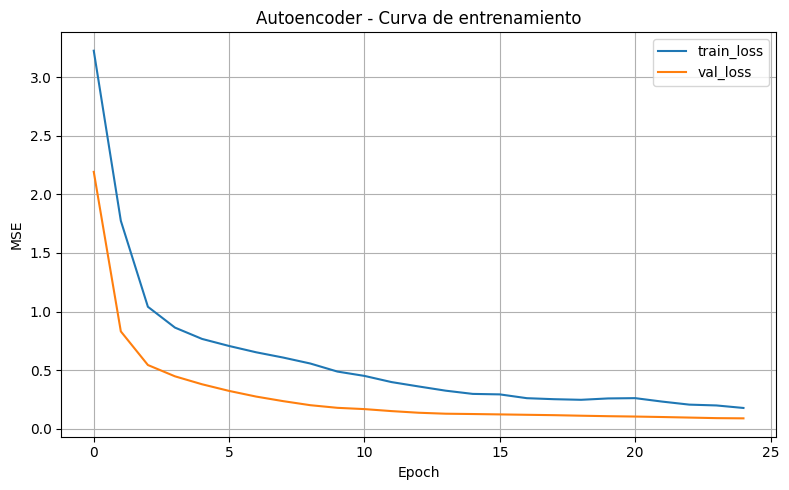

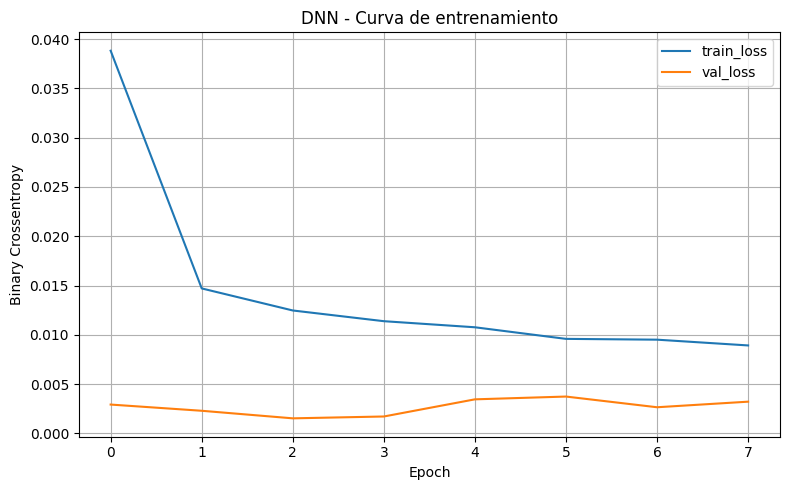

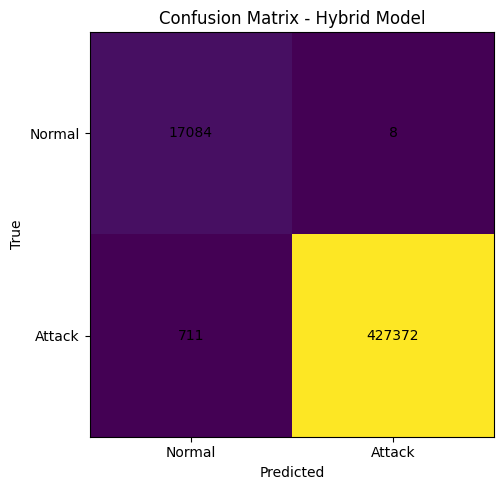

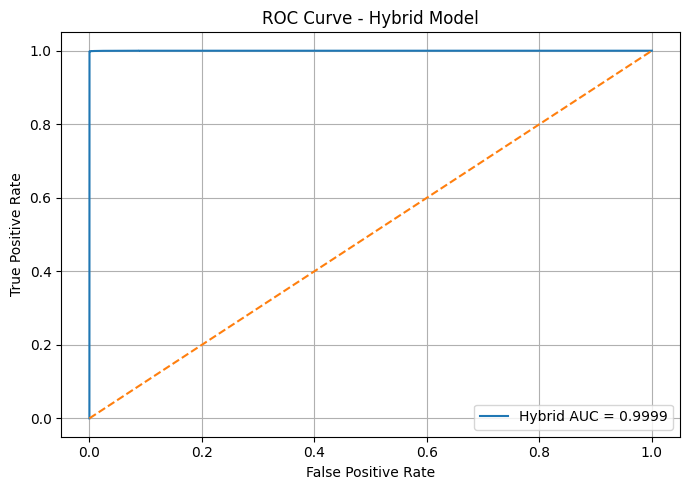

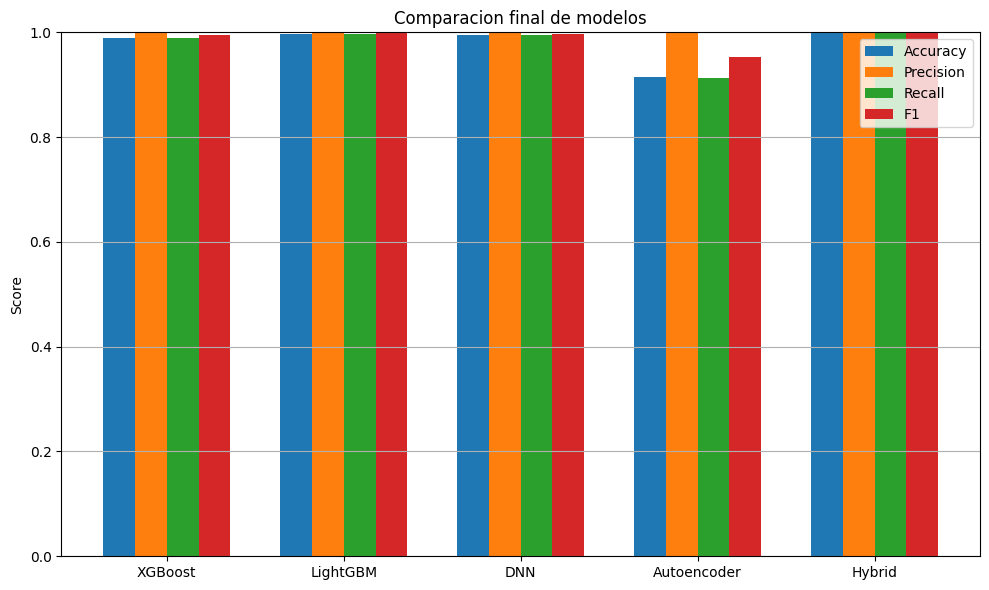

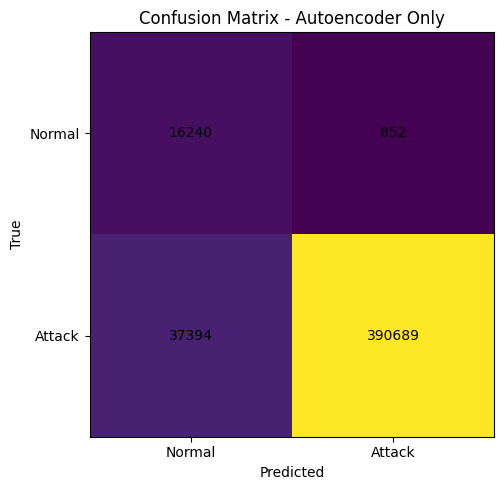

In [21]:
def get_curve(history_dict, split_candidates, metric_candidates):
    for split_name in split_candidates:
        if split_name in history_dict:
            for metric_name in metric_candidates:
                if metric_name in history_dict[split_name]:
                    return history_dict[split_name][metric_name]
    return None

if cfg.use_autoencoder:
    plt.figure(figsize=(8, 5))
    plt.plot(ae_history.history["loss"], label="train_loss")
    plt.plot(ae_history.history["val_loss"], label="val_loss")
    plt.title("Autoencoder - Curva de entrenamiento")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 5))
plt.plot(dnn_history.history["loss"], label="train_loss")
plt.plot(dnn_history.history["val_loss"], label="val_loss")
plt.title("DNN - Curva de entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(cm_hybrid)
plt.title("Confusion Matrix - Hybrid Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["Normal", "Attack"])
plt.yticks([0, 1], ["Normal", "Attack"])
for i in range(cm_hybrid.shape[0]):
    for j in range(cm_hybrid.shape[1]):
        plt.text(j, i, str(cm_hybrid[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, hybrid_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Hybrid AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Hybrid Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
x = np.arange(len(metrics_df.index))
width = 0.18

plt.bar(x - 1.5 * width, metrics_df["accuracy"], width, label="Accuracy")
plt.bar(x - 0.5 * width, metrics_df["precision"], width, label="Precision")
plt.bar(x + 0.5 * width, metrics_df["recall"], width, label="Recall")
plt.bar(x + 1.5 * width, metrics_df["f1"], width, label="F1")

plt.xticks(x, metrics_df.index)
plt.ylim(0, 1)
plt.title("Comparacion final de modelos")
plt.ylabel("Score")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

if cfg.use_autoencoder:
    plt.figure(figsize=(6, 5))
    ae_cm = confusion_matrix(y_test, ae_test_pred)
    plt.imshow(ae_cm)
    plt.title("Confusion Matrix - Autoencoder Only")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks([0, 1], ["Normal", "Attack"])
    plt.yticks([0, 1], ["Normal", "Attack"])
    for i in range(ae_cm.shape[0]):
        for j in range(ae_cm.shape[1]):
            plt.text(j, i, str(ae_cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

20. PKL

In [22]:
carpeta_modelo = "modelo_guardado"
os.makedirs(carpeta_modelo, exist_ok=True)

if cfg.use_autoencoder:
    autoencoder.save(os.path.join(carpeta_modelo, "autoencoder.keras"))
    joblib.dump(
        {
            "threshold": float(ae_threshold),
            "latent_dim": int(cfg.ae_latent_dim),
            "input_dim": int(X_train_final.shape[1]),
            "percentile": int(cfg.ae_threshold_percentile)
        },
        os.path.join(carpeta_modelo, "autoencoder_info.pkl")
    )

paquete_modelo = {
    "xgb": final_xgb,
    "lgbm": final_lgbm,
    "dnn": None,
    "meta_learner": meta_learner,
    "meta_scaler": meta_scaler,
    "scaler": scaler,
    "selector": selector,
    "pca": pca if cfg.use_pca else None,
    "use_pca": cfg.use_pca,
    "use_autoencoder": cfg.use_autoencoder,
    "ae_threshold": float(ae_threshold) if cfg.use_autoencoder else None,
    "feature_names": list(X_train.columns) if hasattr(X_train, "columns") else None
}

paquete_modelo["feature_names"] = feature_names

joblib.dump(
    paquete_modelo,
    os.path.join(carpeta_modelo, "Modelo_hibrido.pkl")
)
joblib.dump(feature_names, os.path.join(carpeta_modelo, "feature_names.pkl"))

final_dnn.save(os.path.join(carpeta_modelo, "dnn_model.keras"))

metrics_df.to_csv(os.path.join(carpeta_modelo, "metrics_summary.csv"))

print("Modelos guardados correctamente en la carpeta:", carpeta_modelo)


Modelos guardados correctamente en la carpeta: modelo_guardado
